    Bernacchia Alessia, Pioda Tommaso, Villani Giacomo
    Data Project and Hackaton 3
    _Sandra Mitròvich_

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import os
import pyarrow.parquet as pq
from tqdm.auto import tqdm
tqdm.pandas()

os.makedirs("data", exist_ok=True)

RANDOM_SEED = 42

# path to the Parquet files folder
CLEANED_DATA_PATH = "data/cleaned_parquet"
SPLIT_DATA_PATH = "data/split"

# utils paths
ID_REGISTRY_PATH = "data/ids_registry.parquet"

# splitting parameters
RANGE_YEARS_FOR_SPLITTING = range(1971, 2025) 
N_TRAIN_PAPERS = 500_000
N_VALIDATION_PAPERS = 150_000  
N_TEST_PAPERS = 150_000


densitz of the graph, how connected the graph is

# B - Split datataset

We consider only papers published between 1971 and 2024 (included). Before 1971 the number of publications per year is very low, while after 2024 not enough papers are available.

The dataset is split into train, validation and test sets using a year‑weighted strategy. The number of papers selected per year is proportional to the actual publication papers of that year.

This approach preserves the real temporal distribution of scientific research and avoids bias. Earlier years are not over‑represented, and more recent years are not under‑sampled, ensuring a more realistic and representative training dataset.

Key features of this implementation:
Shared Logic: The get_year_color function is defined internally to ensure consistent coloring between the weight bar and the paper subplots.

sharex=True: In the 'papers' subplot mode, all three plots share the same X-axis. This makes it visually obvious that the data is partitioned: the Blue bars stop where the Yellow bars begin, and so on.

Automatic Alignment: For the subplots, the code iterates through the entire RANGE_YEARS_FOR_SPLITTING. This ensures that even if a set (like 'Test') only has data for 2020-2024, the plot doesn't "stretch" those bars; it places them correctly at the end of the timeline.

Flexibility: Calling the function without arguments will generate both views, which is useful for a final inspection of your data splitting strategy.

## 1. Downsample from Cleaned Data
- rescale the dataset in a given year range on which focus the study
- balance maintaining the year distribution
- avoid overlapping years between sets
- avoid less than 3 years in a single set to be meaningfull and representative

### 1.1 Identify Years Range
- import the ids_registry to count the publication per year
- define weights to downsample a balanced dataset

In [2]:
try:
    print(f'Read and import file IDs raw data from: {ID_REGISTRY_PATH}')
    ids_registry = pd.read_parquet(ID_REGISTRY_PATH)
    print(f"Found {len(ids_registry)} unique IDs.")
except Exception as e:
    print(f"Error reading the file: {e}")

Read and import file IDs raw data from: data/ids_registry.parquet
Found 6729828 unique IDs.


In [3]:
# years publication 
year_counts = ids_registry['year'].value_counts().sort_index()
# filter for interested years
year_counts = year_counts.loc[year_counts.index.isin(RANGE_YEARS_FOR_SPLITTING)]
# total number of papers available in the interested years
total_available_papers = year_counts.sum()
# weights based on distr of papers per year,
# select more papers from the years with more publications and less from the years with less publications
year_weights = year_counts / total_available_papers

# target total papers
N_TOT = N_TRAIN_PAPERS + N_VALIDATION_PAPERS + N_TEST_PAPERS

### 1.2 Assign Years to Sets in a Chronological Order
- each set assigned to a set of years, at least 3 years to be representative

In [4]:
# cumulative sum to find where the thresholds fall
cumulative_weights = year_weights.cumsum()

# target percentages
train_pct = N_TRAIN_PAPERS / N_TOT
val_pct = N_VALIDATION_PAPERS / N_TOT

# find split years
train_end_year = cumulative_weights[cumulative_weights <= train_pct].index[-1]
val_end_year = cumulative_weights[cumulative_weights <= (train_pct + val_pct)].index[-1]

# define ranges
train_years = [y for y in RANGE_YEARS_FOR_SPLITTING if y <= train_end_year]
val_years = [y for y in RANGE_YEARS_FOR_SPLITTING if train_end_year < y <= val_end_year]
test_years = [y for y in RANGE_YEARS_FOR_SPLITTING if y > val_end_year]

# validation of "at least 3 years" constraint
def check_3_years(years_list, set_name):
    if len(years_list) < 3:
        print(f"WARNING: {set_name} has only {len(years_list)} years. Adjusting...")
        return False
    return True

if not (check_3_years(test_years, "Test") and check_3_years(val_years, "Validation")):
    # Fallback logic: Select last 3 for Test, previous 3 for Val, rest for Train
    all_years = sorted(list(RANGE_YEARS_FOR_SPLITTING))
    test_years = all_years[-3:]
    val_years = all_years[-6:-3]
    train_years = all_years[:-6]
    print(f"Manual override: Train({min(train_years)}-{max(train_years)}), Val({min(val_years)}-{max(val_years)}), Test({min(test_years)}-{max(test_years)})")

### 1.3 Assign papers per year
- assign how many papers to take from each year
- splitting avoiding data leakage, then they wouldn't be in the same time range

In [5]:
def get_papers_per_year(target_total, year_list, weights):
    # original weights but normalized to the subset of years
    subset_weights = weights.loc[year_list]
    normalized_weights = subset_weights / subset_weights.sum()
    
    # calculate count per year
    counts = (normalized_weights * target_total).round().astype(int)
    
    # adjust for rounding errors
    diff = target_total - counts.sum()
    if diff != 0:
        counts.iloc[-1] += diff
    return counts

n_tr_per_year = get_papers_per_year(N_TRAIN_PAPERS, train_years, year_weights)
n_val_per_year = get_papers_per_year(N_VALIDATION_PAPERS, val_years, year_weights)
n_test_per_year = get_papers_per_year(N_TEST_PAPERS, test_years, year_weights)


print(f"Train Years(num of papers {n_tr_per_year.sum()}): {min(train_years)} - {max(train_years)}")
print(f"Val Years(num of papers {n_val_per_year.sum()}): {min(val_years)} - {max(val_years)}")
print(f"Test Years(num of papers {n_test_per_year.sum()}): {min(test_years)} - {max(test_years)}")

Train Years(num of papers 500000): 1971 - 2017
Val Years(num of papers 150000): 2018 - 2021
Test Years(num of papers 150000): 2022 - 2024


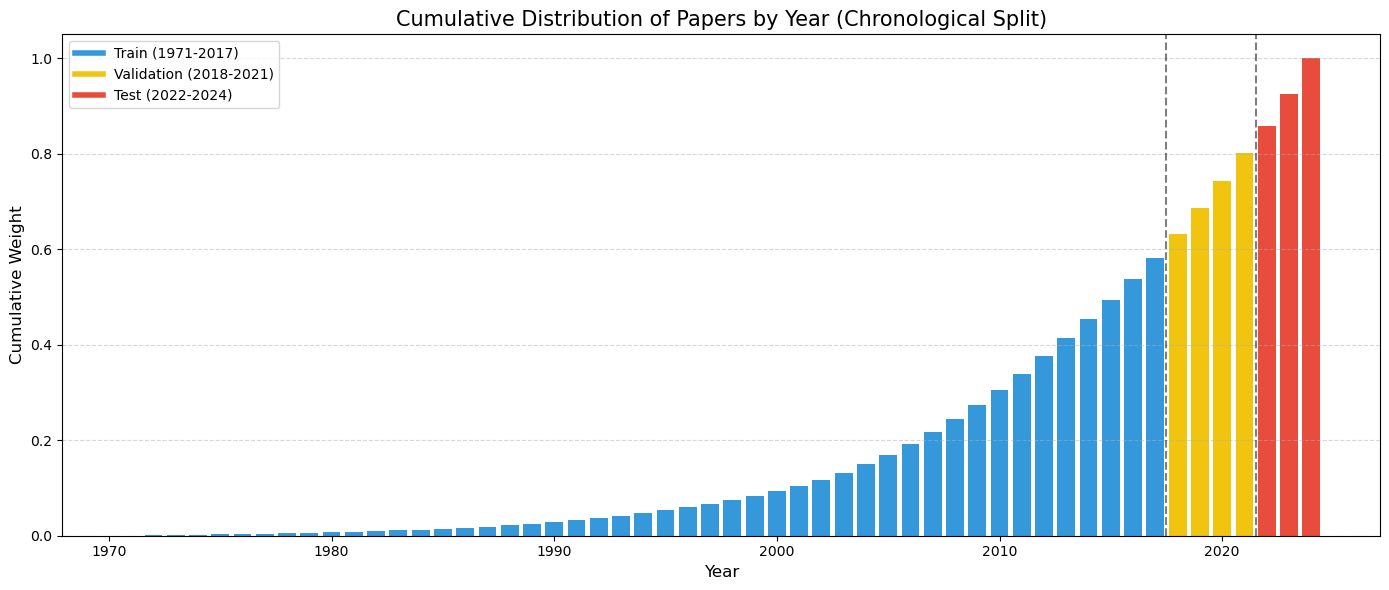

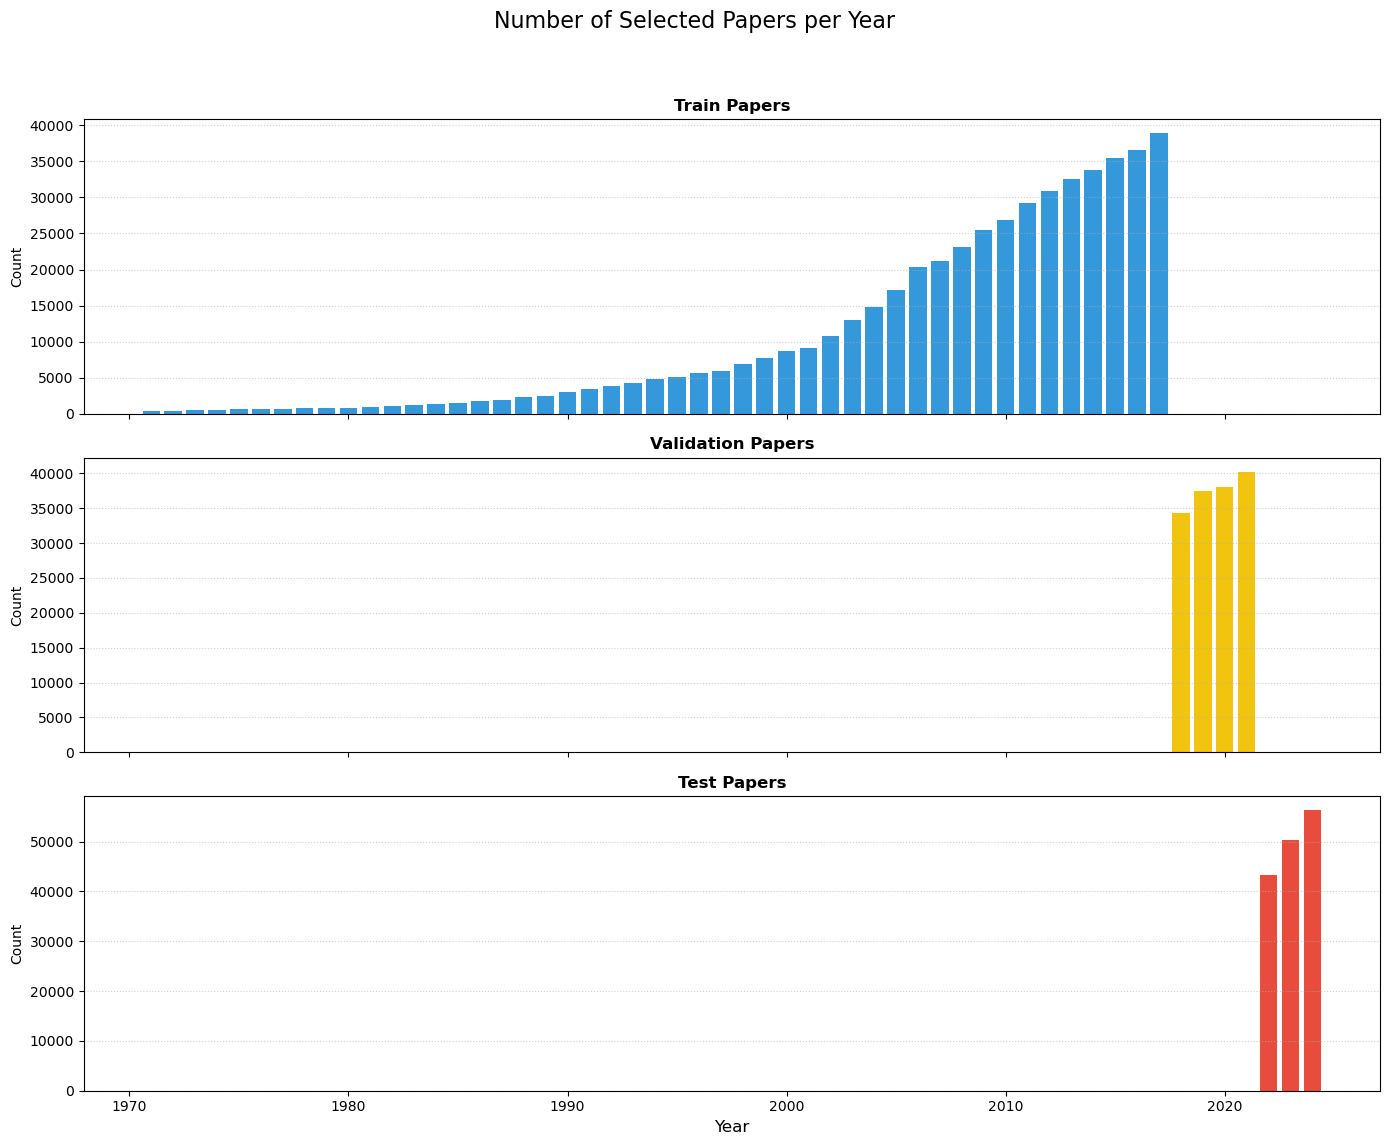

In [6]:
def plot_split_distribution(mode=None):
    """
    Plots the data distribution across years.
    - 'weights': Cumulative distribution of weights.
    - 'papers': Number of papers selected per year (3 subplots).
    - None: Both plots.
    """
    
    # helper to map colors
    def get_year_color(year):
        if year in train_years: return '#3498db' # Blue
        elif year in val_years: return '#f1c40f' # Yellow
        elif year in test_years: return '#e74c3c' # Red
        return '#bdc3c7'

    # legend elements shared by plots
    legend_elements = [
        Line2D([0], [0], color='#3498db', lw=4, label=f'Train ({min(train_years)}-{max(train_years)})'),
        Line2D([0], [0], color='#f1c40f', lw=4, label=f'Validation ({min(val_years)}-{max(val_years)})'),
        Line2D([0], [0], color='#e74c3c', lw=4, label=f'Test ({min(test_years)}-{max(test_years)})')
    ]

    # WEIGHTS PLOT
    if mode == 'weights' or mode is None:
        colors = [get_year_color(y) for y in cumulative_weights.index]
        plt.figure(figsize=(14, 6))
        plt.bar(cumulative_weights.index, cumulative_weights.values, color=colors, width=0.8)
        
        plt.title("Cumulative Distribution of Papers by Year (Chronological Split)", fontsize=15)
        plt.ylabel("Cumulative Weight", fontsize=12)
        plt.xlabel("Year", fontsize=12)
        plt.grid(axis='y', linestyle='--', alpha=0.5)
        plt.legend(handles=legend_elements, loc='upper left')
        
        plt.axvline(x=max(train_years) + 0.5, color='black', linestyle='--', alpha=0.5)
        plt.axvline(x=max(val_years) + 0.5, color='black', linestyle='--', alpha=0.5)
        plt.tight_layout()
        plt.show()

    # PAPERS SUBPLOTS
    if mode == 'papers' or mode is None:
        fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)
        
        # setup for the 3 subplots
        sets_data = [
            (n_tr_per_year, 'Train Papers', '#3498db'),
            (n_val_per_year, 'Validation Papers', '#f1c40f'),
            (n_test_per_year, 'Test Papers', '#e74c3c')
        ]
        
        all_years = sorted(list(RANGE_YEARS_FOR_SPLITTING))

        for i, (data, label, color) in enumerate(sets_data):
            # align the counts with the full range of years to keep the X-axis consistent
            counts_full = [data.get(y, 0) for y in all_years]
            axes[i].bar(all_years, counts_full, color=color, width=0.8)
            axes[i].set_ylabel("Count", fontsize=10)
            axes[i].set_title(label, fontsize=12, fontweight='bold')
            axes[i].grid(axis='y', linestyle=':', alpha=0.6)
            
        plt.xlabel("Year", fontsize=12)
        plt.suptitle("Number of Selected Papers per Year", fontsize=16)
        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()
        
plot_split_distribution()

## 2. Split dataset
- divide in train, validation and test set

In [7]:
train_list, val_list, test_list = [], [], []

def sample_from_year(year, n_needed):
    if n_needed <= 0: return pd.DataFrame()
    path = f"{CLEANED_DATA_PATH}/year_{year}.0.parquet"
    df = pd.read_parquet(path)
    # n=min(n_needed, len(df)) ensures we don't crash if a year is smaller than expected
    return df.sample(n=min(n_needed, len(df)), random_state=42)

for y in tqdm(train_years, desc="Sampling Train"):
    train_list.append(sample_from_year(y, n_tr_per_year[y]))

for y in tqdm(val_years, desc="Sampling Validation"):
    val_list.append(sample_from_year(y, n_val_per_year[y]))

for y in tqdm(test_years, desc="Sampling Test"):
    test_list.append(sample_from_year(y, n_test_per_year[y]))

# final concatenation
train_chunk = pd.concat(train_list, ignore_index=True)
val_chunk = pd.concat(val_list, ignore_index=True)
test_chunk = pd.concat(test_list, ignore_index=True)

# final global shuffle to mix the years within each set
train_chunk = train_chunk.sample(frac=1).reset_index(drop=True)
val_chunk = val_chunk.sample(frac=1).reset_index(drop=True)
test_chunk = test_chunk.sample(frac=1).reset_index(drop=True)

Sampling Train:   0%|          | 0/47 [00:00<?, ?it/s]

Sampling Validation:   0%|          | 0/4 [00:00<?, ?it/s]

Sampling Test:   0%|          | 0/3 [00:00<?, ?it/s]

In [8]:
display(train_chunk.head(3))
display(val_chunk.head(3)) 
display(test_chunk.head(3))

,id,title,lang,doc_type,venue,doi,abstract,year,n_citation,references,keywords,url,authors
0,53e9a8a2b7602d97031eda43,Indentation for Estimating the Human Tongue So...,en,conference,Medical Simulation Lecture Notes in Computer S...,10.1007/978-3-540-25968-8_9,A 3D biomechanical model of the tongue is pres...,2004.0,22.0,[],[Hyperelastic Modeling],"[https://openalex.org/W1871044239, https://do...","[{'id': '668bf8c36a21953c987a9822', 'name': 'J..."
1,599c7afd601a182cd26fa271,Academic Promotion and the H‐index,en,journal,Journal of the American Society for Informatio...,10.1002/asi.22998,Journal of the American Society for Informatio...,2013.0,9.0,"[599c7933601a182cd262206f, 539099a220f70186a0e...",[educational activities],[https://doi.org/10.1002/asi.22998],"[{'id': '53f438e5dabfaee1c0ab5505', 'name': 'A..."
2,5390afc920f70186a0ed20dc,Cross-Layer Optimization for Multimedia Transp...,en,journal,IEEE Transactions on Mobile Computing,10.1109/TMC.2010.230,Most previous work on code division multiple a...,2011.0,23.0,"[558a5a95e4b031bae1f721ee, 539087f320f70186a0d...","[approximation scheme, traffic-adaptive scheme...","[http://dx.doi.org/10.1109/TMC.2010.230, http...","[{'id': '53f63a6bdabfae57b759cf1b', 'name': 'H..."


,id,title,lang,doc_type,venue,doi,abstract,year,n_citation,references,keywords,url,authors
0,5d4d46ff3a55acff992fdee0,Enabling Low Cost Elderly Monitoring for Conne...,en,conference,2019 IEEE International Conference on Smart Co...,10.1109/smartcomp.2019.00079,By introducing the state of the art sensing te...,2019.0,13.0,"[5bdc313a17c44a1f58a03ce4, 5390994d20f70186a0e...","[LPWA, Elderly Monitoring, Connected Community]",[https://www.semanticscholar.org/paper/5180cb2...,"[{'id': '63af98af84ab04bd7fb89b2f', 'name': 'Y..."
1,5da2f8aa3a55ac3402d8c328,Perturbation Analysis of the 8-Point Algorithm...,en,conference,2019 IEEE/CVF Conference on Computer Vision an...,10.1109/cvpr.2019.01203,This paper presents a perturbation analysis fo...,2019.0,33.0,"[53e99e78b7602d970273b1cb, 53e99f02b7602d97027...","[3D from Multiview and Sensors, Motion and Tra...",[https://ieeexplore.ieee.org/document/8953985],"[{'id': '53f42b11dabfaeb22f3e2c77', 'name': 'T..."
2,5d528a3e3a55ac1c22f5b98e,Unconstrained Foreground Object Search,en,conference,2019 IEEE/CVF INTERNATIONAL CONFERENCE ON COMP...,10.1109/iccv.2019.00212,Many people search for foreground objects to u...,2019.0,27.0,"[53e99827b7602d970204b38a, 58d82fcbd649053542f...","[background image, candidate foreground object...",[http://www.webofknowledge.com/],"[{'id': '544868eddabfae857591056f', 'name': 'Y..."


,id,title,lang,doc_type,venue,doi,abstract,year,n_citation,references,keywords,url,authors
0,62708f615aee126c0fa691ff,Improved Reconstruction for Fourier-Sparse Sig...,en,journal,CoRR,10.48550/arxiv.2205.00658,We revisit the classical problem of Fourier-sp...,2022.0,15.0,"[5e4e5ac53a55ac305df4b5c7, 5f859a8f91e011ff328...","[Sparse Approximation, Sparse Representations,...",[http://arxiv.org/abs/2205.00658],"[{'id': '63722274ec88d95668cb075f', 'name': 'Y..."
1,6098f98d91e011aa8bcb6d1d,Accuracy and Stability Analysis of the Semi-La...,en,journal,Multiscale Modeling and Simulation,10.1137/21m141871x,"In this paper, we develop a family of third or...",2023.0,16.0,"[5390ac1820f70186a0eb36f7, 5390990f20f70186a0e...","[hyperbolic relaxation system, BGK model, semi...","[https://openalex.org/W3160591311, https://do...","[{'id': '65d57a12c136ef1331b60661', 'name': 'M..."
2,6134a0bc5244ab9dcb66b8bb,Suppression of Packet Losses and Disturbances ...,en,journal,IEEE TRANSACTIONS ON CYBERNETICS,10.1109/tcyb.2021.3080581,This article presents a method of suppressing ...,2023.0,26.0,"[5390b5c720f70186a0f095e4, 65b8abb9939a5f40829...","[Packet loss, Delay effects, Delays, Predictiv...",[https://ieeexplore.ieee.org/document/9529063],"[{'id': '645bc7d59bb9460001f5eaf3', 'name': 'M..."


## 3. Verify Valid Connectivity
Using graph, verify how well the sets are connected within each other

In [9]:
import networkx as nx
import numpy as np


--- Starting Connectivity Analysis for: Training Set ---
[Training Set] Cleaning and exploding references...
[Training Set] Building the network graph...


Adding edges for Training Set:   0%|          | 0/515959 [00:00<?, ?it/s]

[Training Set] Identifying connected components...
------------------------------

Results for Training Set
	Total Papers (Nodes): 500000
	Total Clusters (Connected Groups): 207770
	Largest Cluster Size: 274743 papers (54.95%)
	Smallest Cluster Size: 1 papers (0.00%)

	Cluster Size Distribution (Frequency):
		- Clusters of size 1: 195592
		- Clusters of size 2: 9180
		- Clusters of size 3: 1906
		- Clusters of size 4: 608
		- Clusters of size 5: 229
		- Clusters of size 6: 103
		- Clusters of size 7: 55
		- Clusters of size 8: 35
		- Clusters of size 9: 15
		- Clusters of size 10: 13
		- Clusters of size 11: 10
		- Clusters of size 12: 9
		- Clusters of size 13: 6
		- Clusters of size 14: 1
		- Clusters of size 15: 2
		- Clusters of size 16: 1
		- Clusters of size 18: 1
		- Clusters of size 23: 1
		- Clusters of size 28: 1
		- Clusters of size 37: 1
		- Clusters of size 274743: 1
[Training Set] Plotting cluster size distribution...


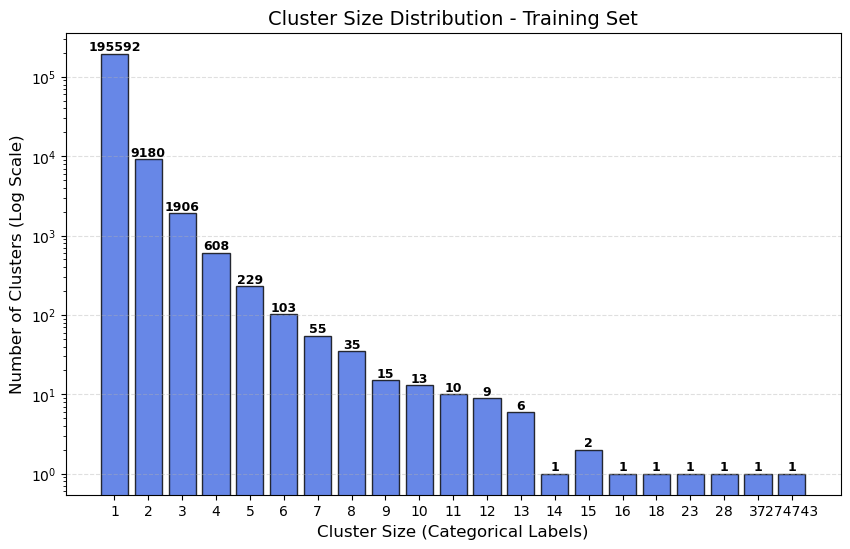


--- Starting Connectivity Analysis for: Test Set ---
[Test Set] Cleaning and exploding references...
[Test Set] Building the network graph...


Adding edges for Test Set:   0%|          | 0/37249 [00:00<?, ?it/s]

[Test Set] Identifying connected components...
------------------------------

Results for Test Set
	Total Papers (Nodes): 150000
	Total Clusters (Connected Groups): 118043
	Largest Cluster Size: 18959 papers (12.64%)
	Smallest Cluster Size: 1 papers (0.00%)

	Cluster Size Distribution (Frequency):
		- Clusters of size 1: 110670
		- Clusters of size 2: 5031
		- Clusters of size 3: 1205
		- Clusters of size 4: 519
		- Clusters of size 5: 235
		- Clusters of size 6: 127
		- Clusters of size 7: 64
		- Clusters of size 8: 57
		- Clusters of size 9: 38
		- Clusters of size 10: 21
		- Clusters of size 11: 17
		- Clusters of size 12: 8
		- Clusters of size 13: 6
		- Clusters of size 14: 6
		- Clusters of size 15: 6
		- Clusters of size 16: 3
		- Clusters of size 17: 5
		- Clusters of size 18: 6
		- Clusters of size 19: 3
		- Clusters of size 20: 3
		- Clusters of size 21: 1
		- Clusters of size 22: 2
		- Clusters of size 23: 1
		- Clusters of size 24: 1
		- Clusters of size 25: 2
		- Clusters

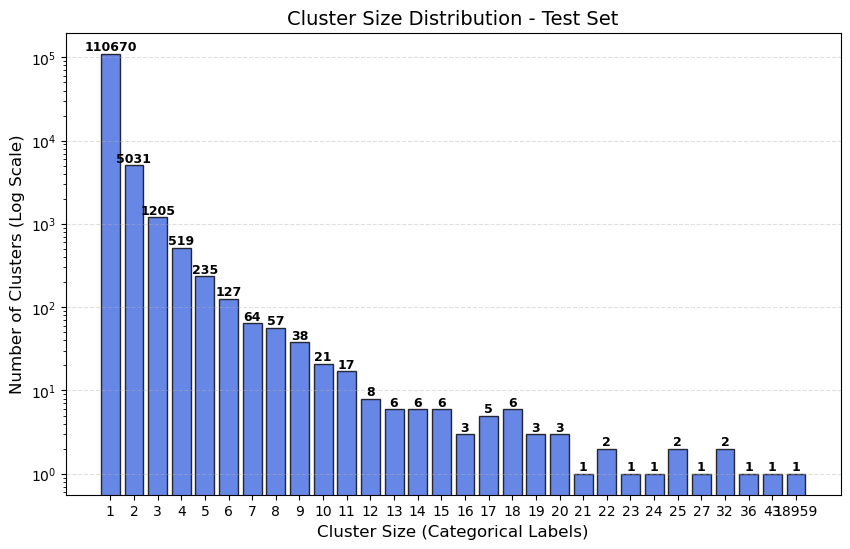

In [ ]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from collections import Counter

def analyze_set_connectivity(df, set_name="Dataset", show_graph=False, show_distribution=False, verbose=True):
    """
    Explodes references, creates a network graph, and calculates comprehensive 
    connectivity statistics including cluster size distributions.
    """
    print(f"\n--- Starting Connectivity Analysis for: {set_name} ---")

    # 1. References Explosion
    # converting NaNs/Floats to empty lists
    print(f"[{set_name}] Cleaning and exploding references...")
    df_clean = df.copy()
    df_clean['references'] = df_clean['references'].apply(
        lambda x: x if isinstance(x, (list, np.ndarray)) else []
    )

    # Explode the dataframe to get (citing_id, cited_id) pairs
    exploded = df_clean[['id', 'references']].explode('references').dropna(subset=['references'])

    # 2. Graph Construction
    print(f"[{set_name}] Building the network graph...")
    G = nx.Graph() # Undirected graph to find interconnected groups (clusters)
    
    # all unique paper IDs as nodes
    all_ids = set(df['id'].unique())
    G.add_nodes_from(all_ids)

    # filter for internal edges only (both citing and cited must be in this set)
    internal_edges = exploded[exploded['references'].isin(all_ids)]
    
    # add edges to the graph
    edges = list(zip(internal_edges['id'], internal_edges['references']))
    for u, v in tqdm(edges, desc=f"Adding edges for {set_name}"):
        G.add_edge(u, v)

    # 3. Connected Components (Clusters) Identification
    print(f"[{set_name}] Identifying connected components...")
    components = sorted(nx.connected_components(G), key=len, reverse=True)
    num_components = len(components)
    total_nodes = len(G)

    if total_nodes == 0:
        print(f"[{set_name}] Error: The dataset is empty.")
        return None

    # 4. Statistics Calculation
    component_sizes = [len(c) for c in components]
    size_counts = Counter(component_sizes) # counts how many clusters have size 1, 2, 5, etc.
    
    largest_cc_size = component_sizes[0]
    smallest_cc_size = component_sizes[-1]

    largest_pct = (largest_cc_size / total_nodes) * 100
    smallest_pct = (smallest_cc_size / total_nodes) * 100

    if verbose: 
        print('-' * 30)
        print(f"\nResults for {set_name}")
        print(f"\tTotal Papers (Nodes): {total_nodes}")
        print(f"\tTotal Clusters (Connected Groups): {num_components}")
        print(f"\tLargest Cluster Size: {largest_cc_size} papers ({largest_pct:.2f}%)")
        print(f"\tSmallest Cluster Size: {smallest_cc_size} papers ({smallest_pct:.2f}%)")
        
        # cluster Size Distribution (Value Counts)
        print(f"\n\tCluster Size Distribution (Frequency):")
        # sort by cluster size for better readability
        for size in sorted(size_counts.keys()):
            count = size_counts[size]
            print(f"\t\t- Clusters of size {size}: {count}")

    # 5. Visualization of the Graph and Cluster Size Distribution
    # graph viz
    if show_graph:
        print(f"[{set_name}] Generating visualization...")
        plt.figure(figsize=(12, 8))
        if total_nodes > 1000:
            print(f"  [Note] Node count > 1000. Visualizing only the largest component for clarity.")
            subgraph = G.subgraph(components[0])
            pos = nx.spring_layout(subgraph, k=0.15, seed=42)
            nx.draw(subgraph, pos, node_size=20, node_color="skyblue", edge_color="silver", alpha=0.6)
        else:
            pos = nx.spring_layout(G, k=0.15, seed=42)
            nx.draw(G, pos, node_size=50, node_color="orange", edge_color="gray", alpha=0.5)
        
        plt.title(f"Network Connectivity - {set_name}")
        plt.show()

    # size distribution viz
    if show_distribution:
        print(f"[{set_name}] Plotting cluster size distribution...")
        plt.figure(figsize=(10, 6))

        # order the size_counts by cluster size
        sorted_size_items = sorted(size_counts.items(), key=lambda x: x[0])

        if len(sorted_size_items) > 30:
            print(f"  [Note] Too many unique sizes ({len(sorted_size_items)}). Showing only the most frequent or largest.")
            display_items = sorted_size_items[:20] + [sorted_size_items[-1]]
        else:
            display_items = sorted_size_items

        labels = [str(item[0]) for item in display_items]
        counts = [item[1] for item in display_items]
        bars = plt.bar(labels, counts, color='royalblue', alpha=0.8, edgecolor='black')

        plt.yscale('log')

        plt.xlabel("Cluster Size (Categorical Labels)", fontsize=12)
        plt.ylabel("Number of Clusters (Log Scale)", fontsize=12)
        plt.title(f"Cluster Size Distribution - {set_name}", fontsize=14)
        plt.grid(axis='y', linestyle='--', alpha=0.4)
        
        # text labels on top of bars
        for bar in bars:
            yval = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2, yval, int(yval), 
                     va='bottom', ha='center', fontsize=9, fontweight='bold')

        plt.show()

    return {
        "num_clusters": num_components,
        "largest_pct": largest_pct,
        "size_distribution": dict(size_counts)
    }

# --- Usage Example ---
results_train = analyze_set_connectivity(train_chunk, "Training Set", show_graph=False, show_distribution=True)
results_test = analyze_set_connectivity(test_chunk, "Test Set", show_graph=False, show_distribution=True)

# OLD

## 7. Export splitted data

In [ ]:
if not os.path.exists(SPLIT_DATA_PATH):
     os.makedirs(SPLIT_DATA_PATH)
     
train_chunk.to_parquet(os.path.join(SPLIT_DATA_PATH, "train.parquet"))
val_chunk.to_parquet(os.path.join(SPLIT_DATA_PATH, "validation.parquet"))  
test_chunk.to_parquet(os.path.join(SPLIT_DATA_PATH, "test.parquet"))